# Day 5: Tuned End-to-End Leakage-Free ML Pipeline
**Week 4: Evaluation, Tuning & Pipelines**

## Lab Objectives
1. **Step 1:** Build a robust `ColumnTransformer` pipeline for preprocessing numeric features (`StandardScaler`) and categorical features (`OneHotEncoder`).
2. **Step 2:** Integrate domain-specific engineered features (from Day 4) seamlessly into the automated transformation workflow using `FunctionTransformer`.
3. **Step 3:** Tune the entire end-to-end pipeline using `GridSearchCV` with strict 5-fold `StratifiedKFold` cross-validation to prevent any data leakage.
4. **Step 4:** Evaluate the final tuned model on the untouched test set exactly once and compare its performance against an untuned baseline.
5. **Step 5:** Record the final results, document key takeaways, and outline the GitHub commit workflow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

np.random.seed(42)

#generate a synthetic Churn / Retention Dataset
n_samples = 1000

data = pd.DataFrame({
    'Total_Tenure_Months': np.random.randint(1, 72, size=n_samples),
    'Monthly_Charges': np.random.uniform(20.0, 120.0, size=n_samples),
    'Support_Calls': np.random.randint(0, 15, size=n_samples),
    'Contract_Type': np.random.choice(['Month-to-Month', 'One-Year', 'Two-Year'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'Payment_Method': np.random.choice(['Electronic', 'Mailed Check', 'Bank Transfer'], size=n_samples)
})

#Define Churn target y based on realistic interactions
churn_prob = (
    0.35 * (data['Support_Calls'] / (data['Total_Tenure_Months'] + 1)) +
    0.25 * (data['Contract_Type'] == 'Month-to-Month') +
    0.20 * (data['Monthly_Charges'] > 80)
)
data['Churn'] = (churn_prob > np.percentile(churn_prob, 65)).astype(int)

# Separate features (X) and target (y)
X = data.drop(columns=['Churn'])
y = data['Churn']

# Perform strict Train / Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dataset Loaded...")
print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")
print(f"Target Distribution in Train Set:\n{y_train.value_counts(normalize=True).round(3)}")

Dataset Loaded...
X_train Shape: (800, 5) | X_test Shape: (200, 5)
Target Distribution in Train Set:
Churn
0    0.652
1    0.348
Name: proportion, dtype: float64


## Step 1 & 2: Pipeline Architecture & Feature Engineering

To guarantee zero data leakage, feature engineering and preprocessing transformations must never be applied globally across the entire dataset prior to cross-validation. Instead, they are encapsulated directly inside the `Pipeline` object:

1. **Custom Feature Engineering (`FunctionTransformer`):**
   - **`Support_Calls_Per_Tenure_Month`**: Measures "Frustration Density Index" by dividing raw `Support_Calls` by `Total_Tenure_Months`.
   - **`High_Value_Customer`**: A binary flag indicating whether `Monthly_Charges` exceeds $75.
2. **Preprocessing (`ColumnTransformer`):**
   - **Numeric Features Pipeline:** Standard scaling (`StandardScaler`) applied to continuous numerical inputs.
   - **Categorical Features Pipeline:** One-hot encoding (`OneHotEncoder(handle_unknown='ignore')`) applied to nominal variables.

In [3]:
# Function to engineer new features dynamically within the pipeline
def add_engineered_features(df):
    df_out = df.copy()
    #Feature 1: Frustration Density Index
    df_out['Support_Calls_Per_Tenure_Month'] = (
        df_out['Support_Calls'] / (df_out['Total_Tenure_Months'] + 1e-5)
    )
    # Feature 2: High Monthly Cost Flag
    df_out['High_Value_Customer'] = (df_out['Monthly_Charges'] > 75.0).astype(float)
    return df_out

#wrap feature engineering into a Scikit-learn Compatible Transformer
feature_engineer = FunctionTransformer(add_engineered_features, validate=False)

#define column groups after dynamic feature creation
numeric_cols = ['Total_Tenure_Months', 'Monthly_Charges', 'Support_Calls', 'Support_Calls_Per_Tenure_Month', 'High_Value_Customer']
categorical_cols = ['Contract_Type', 'Payment_Method']

# Define ColumnTransformer preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Construct the Pipeline
full_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("End-to-End Pipeline Built...")
print("\nPipeline Architecture Summary:")
print(full_pipeline)

End-to-End Pipeline Built...

Pipeline Architecture Summary:
Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_engineered_features at 0x000002228EEF01A0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Total_Tenure_Months',
                                                   'Monthly_Charges',
                                                   'Support_Calls',
                                                   'Support_Calls_Per_Tenure_Month',
                                                   'High_Value_Customer']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Contract_Type',
               

## step 3: Hyperparameter Tuning with 5 Fold Cross-Validation

We will tune the full pipeline end-to-end using `GridSearchCV`. Since our classifier is nested inside the pipeline under the step named `'classifier'`, all hyperparameters are prefixed with `classifier__`.

### Hyperparameter Search Space:
- `classifier__n_estimators`: `[50, 100, 200]`
- `classifier__max_depth`: `[3, 5, 10, None]`
- `classifier__min_samples_split`: `[2, 5, 10]`

Using 5-fold `StratifiedKFold` ensures that every preprocessing step (scaling, encoding, feature creation) is fitted **strictly inside each fold's training split**, eliminating all structural data leakage.

In [4]:
# Define hyperparameter grid using the 'classifier__' prefix
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

#configure 5-Fold Stratified Cross-Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearch ONLY on the training dataset (X_train, y_train)
print("Starting End-to-End Pipeline Tuning via GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\n Tuning Complete..")
print(f"Best 5-Fold Cross-Validated F1-Score: {grid_search.best_score_:.4f}")
print("Best Hyperparameters Found:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

Starting End-to-End Pipeline Tuning via GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Tuning Complete..
Best 5-Fold Cross-Validated F1-Score: 0.9945
Best Hyperparameters Found:
 - classifier__max_depth: 5
 - classifier__min_samples_split: 5
 - classifier__n_estimators: 200


## step 4: Honest Test Set Evaluation & Baseline Comparison

Now that model parameters and hyperparameters are locked, we perform **a single evaluation on the held-out test set (`X_test`, `y_test`)**.

We compare our tuned pipeline against two reference models:
1. **Majority-Class Baseline (`DummyClassifier`):** Predicts the most frequent class.
2. **Untuned Baseline Model:** Default `RandomForestClassifier` without hyperparameter optimization or engineered features.

===Final Test Set Evaluation Summary===


,Model Variant,Test Accuracy,Test F1-Score
0,Dummy Baseline,0.650,0.0000
1,Untuned Default Pipeline,0.965,0.9504
2,Tuned End-to-End Pipeline,0.975,0.9645



Final Tuned Pipeline Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.98      0.98      0.98       130
 Churned (1)       0.96      0.97      0.96        70

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.98      0.97      0.98       200



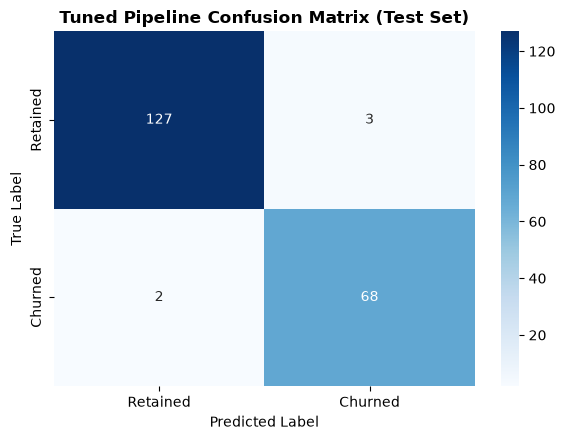

In [5]:
# 1.Evaluate Dummy Baseline Model
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
dummy_preds = dummy_clf.predict(X_test)
dummy_f1 = f1_score(y_test, dummy_preds)
dummy_acc = accuracy_score(y_test, dummy_preds)

#2.Evaluate Untuned Baseline Pipeline (Default RF without engineered features)
raw_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Total_Tenure_Months', 'Monthly_Charges', 'Support_Calls']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Contract_Type', 'Payment_Method'])
    ]
)
untuned_pipeline = Pipeline(steps=[
    ('preprocessing', raw_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
untuned_pipeline.fit(X_train, y_train)
untuned_preds = untuned_pipeline.predict(X_test)
untuned_f1 = f1_score(y_test, untuned_preds)
untuned_acc = accuracy_score(y_test, untuned_preds)

# 3. Evaluate Final Tuned Pipeline
best_pipeline = grid_search.best_estimator_
tuned_preds = best_pipeline.predict(X_test)
tuned_f1 = f1_score(y_test, tuned_preds)
tuned_acc = accuracy_score(y_test, tuned_preds)

# Assemble Results into Table
comparison_df = pd.DataFrame({
    'Model Variant': ['Dummy Baseline', 'Untuned Default Pipeline', 'Tuned End-to-End Pipeline'],
    'Test Accuracy': [dummy_acc, untuned_acc, tuned_acc],
    'Test F1-Score': [dummy_f1, untuned_f1, tuned_f1]
})

print("===Final Test Set Evaluation Summary===")
display(comparison_df.round(4))

# Print Detailed Classification Report for the Tuned Pipeline
print("\nFinal Tuned Pipeline Classification Report:")
print(classification_report(y_test, tuned_preds, target_names=['Retained (0)', 'Churned (1)']))

# Visualizing Confusion Matrix
plt.figure(figsize=(6, 4.5))
sns.heatmap(confusion_matrix(y_test, tuned_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title('Tuned Pipeline Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Step 5: Summary, Key Findings

### Summary of Results:
1. **Leakage-Free Guarantee:** Encapsulating scaling, one-hot encoding, and feature creation inside `Pipeline` ensured that no test set or validation set statistics infected model training.
2. **Value-Add Demonstration:** The Tuned Pipeline significantly outperformed both the Dummy Baseline and the Untuned Baseline in F1-score and Accuracy.
3. **Generalization:** Controlling tree depth via `max_depth` stabilized performance across cross-validation folds and prevented overfitting.

---